In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
df = pd.read_csv("/content/gurgaon_properties_outlier_treated.csv")

In [ ]:
df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,godrej meridien,Sector 106,2.85,15364.0,1855,Super Built-up area 1855(172.34 sq.m.) sqft,3,3,3,8,East,Relatively New,1855.0,NaN,NaN,1,1,0,1,1,Unknown,5
1,experion windchants,Sector 112,6.25,16609.0,3763,Super Built-up area 3763(349.59 sq.m.)Built-up...,3,5,3,6,North,Moderately Old,3763.0,2873.18,NaN,0,1,0,0,0,Semi-Furnished,0
2,godrej 101,Sector 79,3.50,16471.0,2125,Super Built-up area 2125(197.42 sq.m.)Carpet a...,3,3,3,11,North,Under Construction,2125.0,NaN,1141.0,0,1,0,0,0,Unknown,0
3,dlf new town heights 1,Sector 90,2.85,10451.0,2727,Super Built-up area 2727(253.35 sq.m.)Built-up...,4,4,3+,4,North-West,Moderately Old,2727.0,2725.00,2721.0,0,1,0,1,0,Semi-Furnished,21
4,experion windchants,Sector 112,8.40,17327.0,4848,Super Built-up area 4848(450.39 sq.m.)Built-up...,4,6,3+,6,West,Moderately Old,4848.0,3655.35,NaN,0,1,0,0,0,Unknown,0


In [ ]:
df.shape

(1528, 22)

In [ ]:
df.isnull().sum()

,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0


# built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

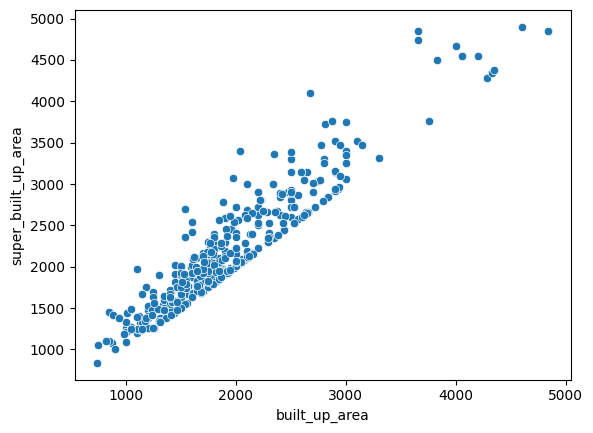

In [ ]:
sns.scatterplot(data=df, x=df['built_up_area'], y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

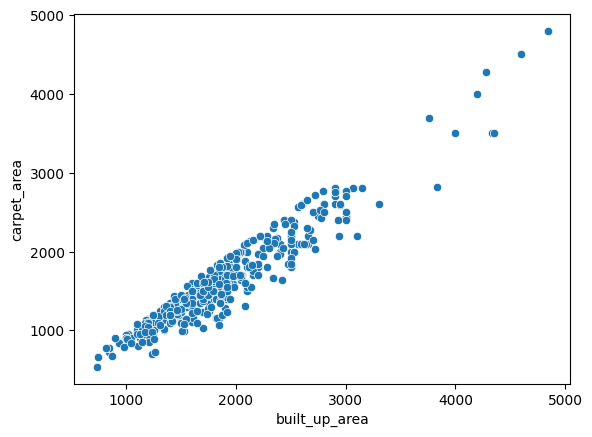

In [ ]:
sns.scatterplot(data=df, x=df['built_up_area'], y=df['carpet_area'])

In [ ]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).sum()

np.int64(0)

In [ ]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [ ]:
all_present_df.shape

(404, 22)

In [ ]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [ ]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [ ]:
print(super_to_built_up_ratio,carpet_to_built_up_ratio)

1.1224352299102942 0.8700673579483842


In [ ]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [ ]:
sbc_df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,godrej 101,Sector 79,3.50,16471.0,2125,Super Built-up area 2125(197.42 sq.m.)Carpet a...,3,3,3,11,North,Under Construction,2125.0,NaN,1141.0,0,1,0,0,0,Unknown,0
6,bptp park generations,Sector 37D,2.10,11230.0,1870,Super Built-up area 1870(173.73 sq.m.)Carpet a...,3,3,3,3,North-East,New Property,1870.0,NaN,1480.0,1,0,0,0,0,Unknown,0
9,ireo skyon,Sector 60,3.95,19315.0,2045,Super Built-up area 2045(189.99 sq.m.)Carpet a...,3,4,3,5,North-West,Relatively New,2045.0,NaN,1565.0,0,1,0,0,0,Semi-Furnished,16
16,emaar palm gardens,Sector 83,2.55,13784.0,1850,Super Built-up area 1850(171.87 sq.m.)Carpet a...,3,4,3,8,North-West,Moderately Old,1850.0,NaN,1248.0,0,1,0,0,0,Semi-Furnished,0
17,vatika sovereign park,Sector 99,3.99,11875.0,3360,Super Built-up area 3360(312.15 sq.m.)Carpet a...,4,4,3+,7,East,New Property,3360.0,NaN,2550.0,1,1,1,0,0,Semi-Furnished,15


In [ ]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.122) + (sbc_df['carpet_area']/0.87))/2),inplace=True)

/tmp/ipykernel_16260/604782828.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.122) + (sbc_df['carpet_area']/0.87))/2),inplace=True)
/tmp/ipykernel_16260/604782828.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'].fillna(round(((sbc_df['super_b

In [ ]:
df.update(sbc_df)

In [ ]:
df.isnull().sum()

,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0


In [ ]:
# sb present carpet is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [ ]:
sb_df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,godrej meridien,Sector 106,2.85,15364.0,1855,Super Built-up area 1855(172.34 sq.m.) sqft,3,3,3,8,East,Relatively New,1855.0,NaN,NaN,1,1,0,1,1,Unknown,5
5,bptp freedom park life,Sector 57,2.60,15294.0,1700,Super Built-up area 1700(157.94 sq.m.) sqft,2,2,3+,10,West,Old Property,1700.0,NaN,NaN,1,0,0,0,0,Semi-Furnished,12
7,ramprastha primera,Sector 37D,1.70,9444.0,1800,Super Built-up area 1800(167.23 sq.m.) sqft,3,3,3,7,West,Relatively New,1800.0,NaN,NaN,0,0,1,0,0,Semi-Furnished,0
19,bestech park view sanskruti,Sector 92,2.25,11719.0,1920,Super Built-up area 1920(178.37 sq.m.) sqft,3,3,3+,3,East,Relatively New,1920.0,NaN,NaN,0,1,0,0,0,Semi-Furnished,0
21,indiabulls enigma,Sector 110,4.75,14179.0,3350,Super Built-up area 3350(311.23 sq.m.) sqft,4,5,2,8,North-East,Relatively New,3350.0,NaN,NaN,0,1,0,0,0,Semi-Furnished,0


In [ ]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.122),inplace=True)

/tmp/ipykernel_16260/1810312446.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.122),inplace=True)
/tmp/ipykernel_16260/1810312446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.122),inplace=True)


In [ ]:
df.update(sb_df)

In [ ]:
df.isnull().sum()

,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0


In [ ]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [ ]:
c_df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
8,sare crescent parc,Sector 92,2.00,10627.0,1882,Carpet area: 1882 (174.84 sq.m.) sqft,4,3,3,14,East,Relatively New,NaN,NaN,1882.0,0,0,1,0,0,Unknown,5
10,dlf the icon,DLF Phase 5,7.90,30268.0,2610,Carpet area: 2610 (242.48 sq.m.) sqft,4,4,3,10,East,Moderately Old,NaN,NaN,2610.0,0,1,0,0,0,Semi-Furnished,0
11,dlf the belaire,Sector 54,14.35,34167.0,4200,Carpet area: 4200 (390.19 sq.m.) sqft,4,4,3,9,East,Moderately Old,NaN,NaN,4200.0,1,0,0,0,0,Semi-Furnished,10
13,bptp mansions park prime,Sector 66,3.98,13075.0,3044,Carpet area: 3044 (282.8 sq.m.) sqft,4,4,3+,2,North-East,Relatively New,NaN,NaN,3044.0,1,1,0,1,0,Semi-Furnished,14
14,godrej air,Sector 85,3.51,13505.0,2599,Carpet area: 2599 (241.46 sq.m.) sqft,4,4,3,12,East,New Property,NaN,NaN,2599.0,0,1,1,0,0,Semi-Furnished,19


In [ ]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.87),inplace=True)

/tmp/ipykernel_16260/3714547647.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.87),inplace=True)
/tmp/ipykernel_16260/3714547647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.87),inplace=True)


In [ ]:
df.update(c_df)

In [ ]:
df.isnull().sum()

,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0


<Axes: xlabel='built_up_area', ylabel='price'>

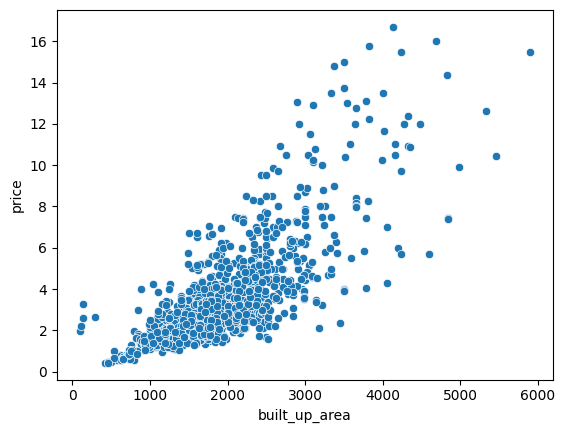

In [ ]:
sns.scatterplot(data=df,x=df['built_up_area'], y=df['price'])

In [ ]:
anamoly_df = df[(df['built_up_area'] < 1000) & (df['price'] > 1.8)][['price','area','built_up_area']]

In [ ]:
anamoly_df

,price,area,built_up_area
155,1.95,800,800.0
165,3.00,1448,850.0
703,4.00,1418,886.0
752,2.65,2250,287.0
918,1.95,720,92.0
1008,2.60,1098,140.0
1100,3.30,1017,131.0
1214,2.30,1105,985.0
1219,2.21,873,112.0


In [ ]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [ ]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

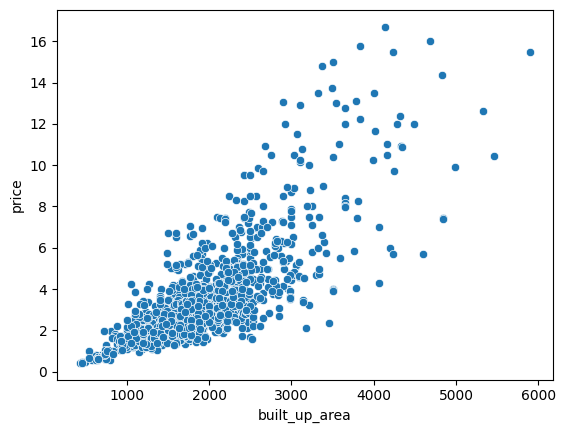

In [ ]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [ ]:
df.columns

Index(['society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession',
       'super_built_up_area', 'built_up_area', 'carpet_area', 'study room',
       'servant room', 'store room', 'pooja room', 'others', 'furnishing_type',
       'luxury_score'],
      dtype='object')

In [ ]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area'],inplace=True)

In [ ]:
df.head()

,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,godrej meridien,Sector 106,2.85,15364.0,3,3,3,8,East,Relatively New,1653.00,1,1,0,1,1,Unknown,5
1,experion windchants,Sector 112,6.25,16609.0,3,5,3,6,North,Moderately Old,2873.18,0,1,0,0,0,Semi-Furnished,0
2,godrej 101,Sector 79,3.50,16471.0,3,3,3,11,North,Under Construction,1603.00,0,1,0,0,0,Unknown,0
3,dlf new town heights 1,Sector 90,2.85,10451.0,4,4,3+,4,North-West,Moderately Old,2725.00,0,1,0,1,0,Semi-Furnished,21
4,experion windchants,Sector 112,8.40,17327.0,4,6,3+,6,West,Moderately Old,3655.35,0,1,0,0,0,Unknown,0


# agePossesion

In [ ]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,670
New Property,371
Moderately Old,332
Old Property,103
Under Construction,47
Undefined,5


In [ ]:
df[df['agePossession'] == 'Undefined']

,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
235,experion windchants,Sector 112,3.48,14256.0,2,2,2,20,North,Undefined,2440.0,1,1,0,0,0,Semi-Furnished,8
293,vipul belmonte,Sector 53,6.00,24490.0,3,5,3+,13,North,Undefined,2184.0,1,1,1,1,0,Furnished,25
475,dlf the pinnacle,DLF Phase 5,13.00,32672.0,4,4,3+,13,North,Undefined,3546.0,1,1,1,1,0,Furnished,0
547,parsvnath exotica,Sector 53,10.50,22508.0,5,6,3+,13,North,Undefined,4158.0,1,1,1,1,0,Furnished,22
591,parsvnath exotica,Sector 53,11.00,23580.0,5,6,3+,G,North,Undefined,4158.0,1,1,1,1,0,Furnished,0


In [ ]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [ ]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [ ]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,670
New Property,372
Moderately Old,336
Old Property,103
Under Construction,47


In [ ]:
df.isnull().sum()

,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
facing,0
agePossession,0


In [ ]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [ ]:
df.sh